# Creative Feature Deep Dive: Ad Creative as a Personalization Signal

## Research Context

MMP (Mobile Measurement Partner) data includes not only touchpoint-level ad journey information,
but also **creative-level data** — the actual ad images, OCR-extracted text, and LLM-classified
message types that users saw before installing.

**Key Question**: Does the creative content a user saw before installing predict their post-install behavior?
If so, this opens an additional personalization signal beyond basic ad journey features.

**Coverage Challenge**: Only ~13.4% of users have any creative URL, and only ~4.1% have fully analyzable
creative data. This analysis explores whether the signal justifies expanding creative data collection.

---

In [1]:
# === Setup ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
C_PRIMARY, C_SECONDARY, C_ACCENT, C_WARN = '#2563EB', '#64748B', '#F59E0B', '#EF4444'

print('Setup complete.')

Setup complete.


In [2]:
# === Data Loading ===
df_raw = pd.read_csv('coldstart_dataset_260301.csv')
df = df_raw[df_raw['IS_HAS_FRAUD'] != 1].copy()
print(f'Total users (fraud excluded): {len(df):,}')

# Parse InApp JSON for M10 features
INAPP_KEYS = ['active', 'ad_engagement', 'core_engagement', 'deeplink_count',
              'open_count', 'purchase_engagement', 'totalEventCount']
parsed = df['inapp_m10'].apply(lambda x: json.loads(x) if pd.notna(x) else {})
for key in INAPP_KEYS:
    df[f'inapp_m10_{key}'] = parsed.apply(lambda d: d.get(key, 0))

# Define feature groups
DEVICE_FEATURES = ['OS_NAME', 'DEVICE_MANUFACTURER', 'DEVICE_LANGUAGE',
                   'DEVICE_TIMEZONE', 'DEVICE_OSVERSION', 'DEVICE_CARRIER']

UA_FEATURES = [
    'has_touchpoint', 'has_last_touch', 'last_touch_is_trackinglink',
    'last_touch_is_da', 'last_touch_is_sa', 'has_term',
    'is_single_touch_install', 'last_is_click', 'last_is_impression',
    'first_is_click', 'first_is_impression',
    'latency', 'touch_window', 'touch_per_window_hour', 'recency',
    'recent_touch_pressure', 'recent_24h_ratio', 'recent_24h_multiple',
    'DA_count', 'SA_count', 'total_touch_count', 'trackinglink_count',
    'unique_channel_count', 'channel_entropy',
    'term_total_count', 'term_unique_count',
    'last30min_touch_count', 'last1h_touch_count', 'last3h_touch_count',
    'last12h_touch_count', 'last24h_touch_count',
    'touch_per_latency_day', 'touch_per_latency_hour',
    'click_count', 'impression_count', 'click_ratio',
    'has_gm_touchpoint',
]
UA_FEATURES = [f for f in UA_FEATURES if f in df.columns]

IMAGE_FEATURES = ['brightness_mean', 'saturation_mean', 'color_entropy',
                  'edge_density', 'symmetry_score', 'hue_sin', 'hue_cos',
                  'vertical_symmetry_score']
LLM_FEATURES = [c for c in df.columns if c.startswith('llm_')]
RULE_FEATURES = [c for c in df.columns if c.startswith('rule_')]
CREATIVE_FEATURES = IMAGE_FEATURES + LLM_FEATURES + RULE_FEATURES + ['has_ocr_text']
CREATIVE_FEATURES = [c for c in CREATIVE_FEATURES if c in df.columns]

print(f'Image features: {len(IMAGE_FEATURES)}')
print(f'LLM features: {len(LLM_FEATURES)}')
print(f'Rule features: {len(RULE_FEATURES)}')
print(f'Total creative features: {len(CREATIVE_FEATURES)}')

Total users (fraud excluded): 385,025


Image features: 8
LLM features: 8
Rule features: 15
Total creative features: 32


---
# Part 1: Creative Data Coverage and Structure

**Question**: How much creative data exists, and what does it look like?

In [3]:
# === 1.1 Creative Coverage Breakdown ===
has_url = df['has_any_creative_url'] == 1
has_usable = df['has_usable_creative'] == 1
has_broken = (df['has_broken_image'] == 1)
has_ocr = df['has_ocr_text'] == 1
any_llm = df[LLM_FEATURES].sum(axis=1) > 0
any_rule = df[RULE_FEATURES].sum(axis=1) > 0

print('=' * 70)
print('CREATIVE DATA COVERAGE')
print('=' * 70)
print(f'Total users: {len(df):,}')
print(f'\n{"Group":<45} {"N":>8} {"Coverage":>8}')
print('-' * 65)
print(f'{"No creative URL":<45} {(~has_url).sum():>8,} {(~has_url).mean()*100:>7.1f}%')
print(f'{"Has creative URL (any)":<45} {has_url.sum():>8,} {has_url.mean()*100:>7.1f}%')
print(f'{"  Usable creative (image analyzable)":<45} {has_usable.sum():>8,} {has_usable.mean()*100:>7.1f}%')
print(f'{"  Broken image (Meta catalog etc.)":<45} {(has_url & has_broken & ~has_usable).sum():>8,} {(has_url & has_broken & ~has_usable).mean()*100:>7.1f}%')
print(f'{"Has OCR text":<45} {has_ocr.sum():>8,} {has_ocr.mean()*100:>7.1f}%')
print(f'{"Has any LLM-classified message":<45} {any_llm.sum():>8,} {any_llm.mean()*100:>7.1f}%')
print(f'{"Has any rule-based keyword":<45} {any_rule.sum():>8,} {any_rule.mean()*100:>7.1f}%')

# Channel breakdown of broken image users
broken_users = df[has_url & has_broken & ~has_usable]
print(f'\n--- Broken Image Users Channel Breakdown (N={len(broken_users):,}) ---')
print(f'  DA (display ad): {broken_users["last_touch_is_da"].mean()*100:.1f}%')
print(f'  SA (search ad):  {broken_users["last_touch_is_sa"].mean()*100:.1f}%')
print(f'  → Mostly Meta/Facebook catalog ads where creative cannot be scraped')

CREATIVE DATA COVERAGE
Total users: 385,025

Group                                                N Coverage
-----------------------------------------------------------------
No creative URL                                333,516    86.6%
Has creative URL (any)                          51,509    13.4%
  Usable creative (image analyzable)            15,955     4.1%
  Broken image (Meta catalog etc.)              35,554     9.2%
Has OCR text                                    14,718     3.8%
Has any LLM-classified message                  13,618     3.5%
Has any rule-based keyword                      11,154     2.9%

--- Broken Image Users Channel Breakdown (N=35,554) ---
  DA (display ad): 70.2%
  SA (search ad):  8.7%
  → Mostly Meta/Facebook catalog ads where creative cannot be scraped


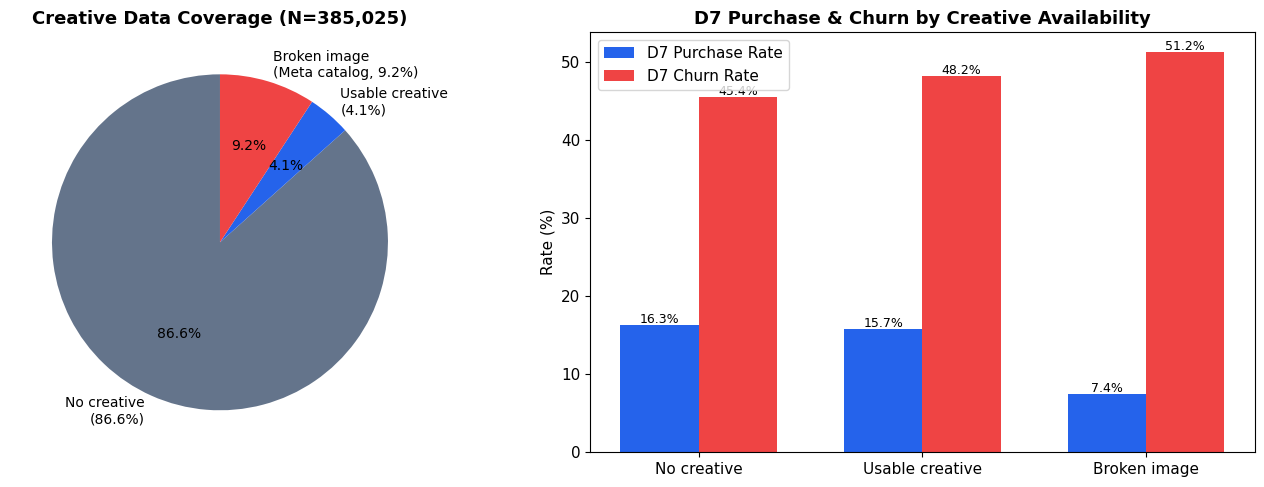

Saved: fig_creative_coverage.png


In [4]:
# === 1.2 Coverage Visualization ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of creative coverage
sizes = [(~has_url).sum(), (has_url & has_usable).sum(),
         (has_url & has_broken & ~has_usable).sum()]
labels = ['No creative\n(86.6%)', 'Usable creative\n(4.1%)', 'Broken image\n(Meta catalog, 9.2%)']
colors = [C_SECONDARY, C_PRIMARY, C_WARN]
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Creative Data Coverage (N=385,025)', fontsize=13, fontweight='bold')

# Bar chart of purchase/churn by group
groups = ['No creative', 'Usable creative', 'Broken image']
masks = [~has_url, has_usable, has_url & has_broken & ~has_usable]
purchase_rates = [df.loc[m, 'IS_D7_PURCHASE'].mean() for m in masks]
churn_rates = [df.loc[m, 'IS_D7_CHURN'].mean() for m in masks]

x = np.arange(len(groups))
w = 0.35
bars1 = axes[1].bar(x - w/2, [r*100 for r in purchase_rates], w, label='D7 Purchase Rate', color=C_PRIMARY)
bars2 = axes[1].bar(x + w/2, [r*100 for r in churn_rates], w, label='D7 Churn Rate', color=C_WARN)
axes[1].set_xticks(x)
axes[1].set_xticklabels(groups)
axes[1].set_ylabel('Rate (%)')
axes[1].set_title('D7 Purchase & Churn by Creative Availability', fontsize=13, fontweight='bold')
axes[1].legend()
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.1f}%', ha='center', fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_creative_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_creative_coverage.png')

---
# Part 2: Message Type Analysis — What the Ad Said Matters

**Question**: Does the *message content* of the ad creative predict post-install behavior?

We analyze two types of text signals extracted from creative images:
- **LLM features**: GPT-classified message categories (brand trust, price discount, urgency, etc.)
- **Rule features**: Keyword-based detection (coupon, sale, percent off, etc.)

In [5]:
# === 2.1 LLM Message Type → Purchase Rate ===
print('=' * 70)
print('LLM-CLASSIFIED MESSAGE TYPE → D7 PURCHASE RATE')
print('(Within usable creative users, N=15,955)')
print('=' * 70)

usable = df[has_usable].copy()
base_rate = usable['IS_D7_PURCHASE'].mean()
print(f'\nBaseline purchase rate (usable creative): {base_rate:.1%}\n')

results_llm = []
for col in sorted(LLM_FEATURES):
    has_feat = usable[col] == 1
    n = has_feat.sum()
    if n >= 50:
        rate_with = usable.loc[has_feat, 'IS_D7_PURCHASE'].mean()
        rate_without = usable.loc[~has_feat, 'IS_D7_PURCHASE'].mean()
        # Chi-squared test
        ct = pd.crosstab(usable[col], usable['IS_D7_PURCHASE'])
        chi2, p, _, _ = chi2_contingency(ct)
        results_llm.append({
            'feature': col.replace('llm_', ''),
            'n': n, 'rate': rate_with, 'base': rate_without,
            'diff': rate_with - rate_without, 'p': p
        })

print(f'{"Message Type":<25} {"N":>6} {"Purchase":>9} {"Baseline":>9} {"Diff":>8} {"p-value":>10}')
print('-' * 72)
for r in sorted(results_llm, key=lambda x: -x['diff']):
    sig = '***' if r['p'] < 0.001 else '**' if r['p'] < 0.01 else '*' if r['p'] < 0.05 else ''
    print(f'{r["feature"]:<25} {r["n"]:>6,} {r["rate"]:>8.1%} {r["base"]:>8.1%} {r["diff"]:>+7.1%}p {r["p"]:>9.2e} {sig}')

LLM-CLASSIFIED MESSAGE TYPE → D7 PURCHASE RATE
(Within usable creative users, N=15,955)

Baseline purchase rate (usable creative): 15.7%

Message Type                   N  Purchase  Baseline     Diff    p-value
------------------------------------------------------------------------
brand_trust                8,177    16.9%    14.5%   +2.4%p  3.21e-05 ***
urgency_scarcity           5,774    15.7%    15.7%   -0.0%p  9.92e-01 
price_discount            10,815    15.6%    16.0%   -0.3%p  5.91e-01 
call_to_action             3,415    15.1%    15.9%   -0.9%p  2.24e-01 
target_specific            3,992    14.5%    16.2%   -1.7%p  1.25e-02 *
product_attribute          5,608    14.3%    16.5%   -2.2%p  2.66e-04 ***
reward_benefit             1,828    13.3%    16.1%   -2.8%p  2.56e-03 **
social_proof                 839    13.0%    15.9%   -2.9%p  2.81e-02 *


In [6]:
# === 2.2 Rule-Based Keywords → Purchase Rate ===
print('=' * 70)
print('RULE-BASED KEYWORDS → D7 PURCHASE RATE')
print('(Within usable creative users, N=15,955)')
print('=' * 70)

results_rule = []
for col in sorted(RULE_FEATURES):
    has_feat = usable[col] == 1
    n = has_feat.sum()
    if n >= 30:
        rate_with = usable.loc[has_feat, 'IS_D7_PURCHASE'].mean()
        rate_without = usable.loc[~has_feat, 'IS_D7_PURCHASE'].mean()
        ct = pd.crosstab(usable[col], usable['IS_D7_PURCHASE'])
        chi2, p, _, _ = chi2_contingency(ct)
        results_rule.append({
            'feature': col.replace('rule_', ''),
            'n': n, 'rate': rate_with, 'base': rate_without,
            'diff': rate_with - rate_without, 'p': p
        })

print(f'\n{"Keyword Type":<25} {"N":>6} {"Purchase":>9} {"Baseline":>9} {"Diff":>8} {"p-value":>10}')
print('-' * 72)
for r in sorted(results_rule, key=lambda x: -x['diff']):
    sig = '***' if r['p'] < 0.001 else '**' if r['p'] < 0.01 else '*' if r['p'] < 0.05 else ''
    print(f'{r["feature"]:<25} {r["n"]:>6,} {r["rate"]:>8.1%} {r["base"]:>8.1%} {r["diff"]:>+7.1%}p {r["p"]:>9.2e} {sig}')

RULE-BASED KEYWORDS → D7 PURCHASE RATE
(Within usable creative users, N=15,955)

Keyword Type                   N  Purchase  Baseline     Diff    p-value
------------------------------------------------------------------------
first_come                   118    20.3%    15.7%   +4.6%p  2.11e-01 
half_price                   744    19.4%    15.6%   +3.8%p  6.47e-03 **
benefit_word                 410    17.3%    15.7%   +1.6%p  4.12e-01 
today_only                   384    17.2%    15.7%   +1.5%p  4.72e-01 
black_friday               7,250    16.5%    15.1%   +1.3%p  2.19e-02 *
up_to                      1,172    16.7%    15.7%   +1.1%p  3.57e-01 
sold_out                     526    16.5%    15.7%   +0.8%p  6.51e-01 
percent                    7,686    16.0%    15.5%   +0.4%p  4.90e-01 
date_format                5,704    16.0%    15.6%   +0.4%p  5.31e-01 
special_price              2,161    15.9%    15.7%   +0.2%p  8.29e-01 
discount_word              3,900    15.8%    15.7%   +0.1%p 

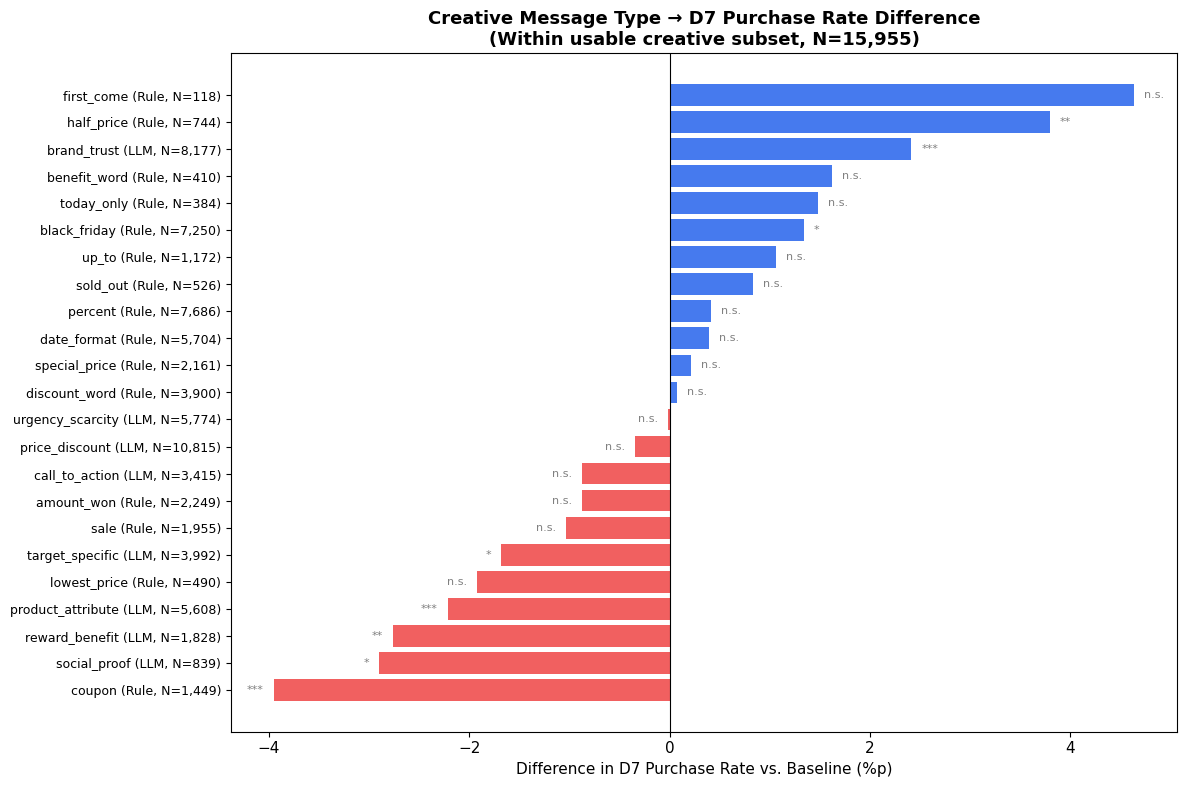

Saved: fig_creative_message_types.png


In [7]:
# === 2.3 Message Type Visualization ===
# Combine LLM and rule results
all_results = []
for r in results_llm:
    all_results.append({**r, 'source': 'LLM', 'label': r['feature']})
for r in results_rule:
    if r['n'] >= 100:  # Only plot rules with enough data
        all_results.append({**r, 'source': 'Rule', 'label': r['feature']})

all_results.sort(key=lambda x: x['diff'])

fig, ax = plt.subplots(figsize=(12, 8))
colors = [C_WARN if r['diff'] < 0 else C_PRIMARY for r in all_results]
labels = [f"{r['label']} ({r['source']}, N={r['n']:,})" for r in all_results]
diffs = [r['diff'] * 100 for r in all_results]

bars = ax.barh(range(len(all_results)), diffs, color=colors, alpha=0.85)
ax.set_yticks(range(len(all_results)))
ax.set_yticklabels(labels, fontsize=9)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Difference in D7 Purchase Rate vs. Baseline (%p)')
ax.set_title('Creative Message Type → D7 Purchase Rate Difference\n(Within usable creative subset, N=15,955)', fontsize=13, fontweight='bold')

# Add significance markers
for i, r in enumerate(all_results):
    marker = '***' if r['p'] < 0.001 else '**' if r['p'] < 0.01 else '*' if r['p'] < 0.05 else 'n.s.'
    ax.text(diffs[i] + (0.1 if diffs[i] >= 0 else -0.1), i, marker,
            va='center', ha='left' if diffs[i] >= 0 else 'right', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('fig_creative_message_types.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_creative_message_types.png')

---
# Part 3: Image Features Analysis

**Question**: Do visual properties of the ad creative (brightness, saturation, color entropy, etc.) predict post-install behavior?

IMAGE FEATURE CORRELATIONS WITH D7 PURCHASE
(Within users with image features, N=11,252)

Users with image features: 11,252

Feature                        Corr (purchase)    Corr (churn)     Mean      Std
--------------------------------------------------------------------------------
brightness_mean                       -0.0262        +0.0028    0.602    0.246
saturation_mean                       +0.0065        -0.0205    0.443    0.304
color_entropy                         +0.0057        -0.0016    4.757    2.401
edge_density                          +0.0084        -0.0025    0.025    0.020
symmetry_score                        +0.0089        +0.0027    0.876    0.077
hue_sin                               -0.0162        +0.0165   -0.093    0.383
hue_cos                               -0.0066        +0.0302    0.192    0.648
vertical_symmetry_score               -0.0018        +0.0009    0.785    0.120

** All correlations are near zero — image features show no meaningful signal **


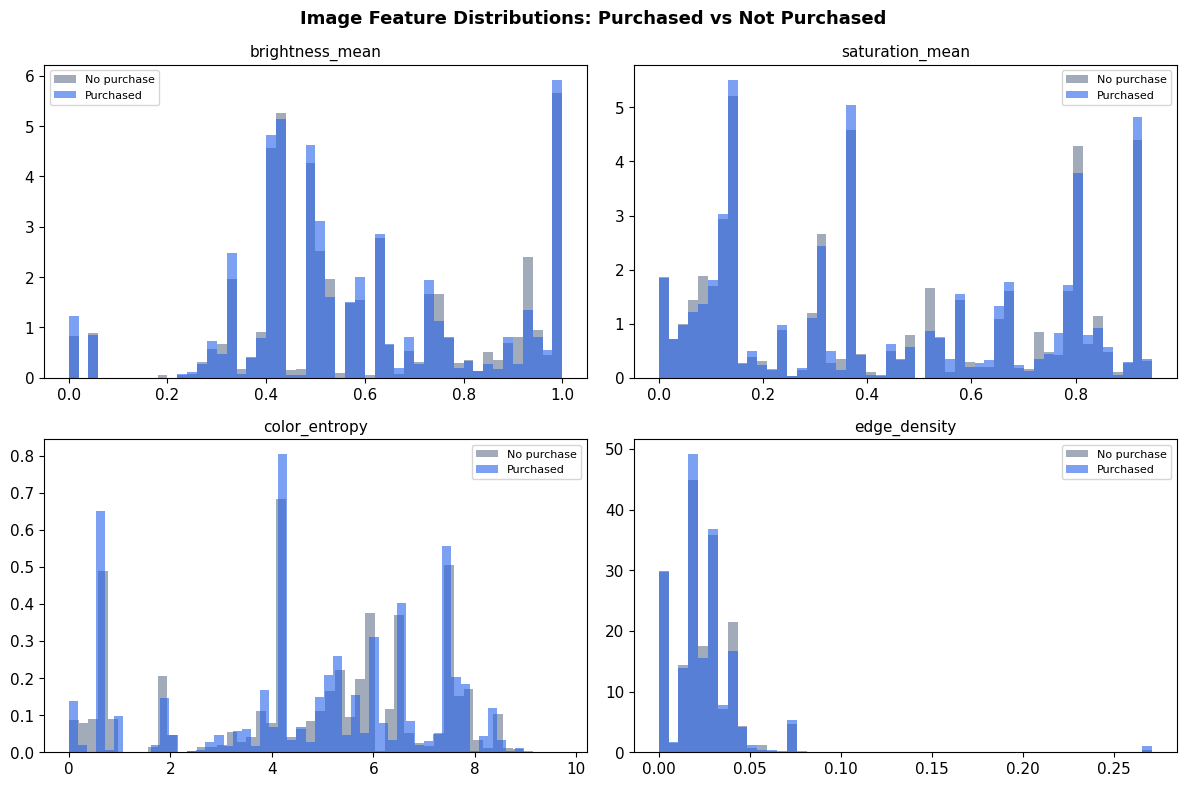

Saved: fig_creative_image_features.png


In [8]:
# === 3.1 Image Feature Correlations ===
print('=' * 70)
print('IMAGE FEATURE CORRELATIONS WITH D7 PURCHASE')
print('(Within users with image features, N=11,252)')
print('=' * 70)

img_users = df[df['brightness_mean'].notna()].copy()
print(f'\nUsers with image features: {len(img_users):,}\n')

print(f'{"Feature":<30} {"Corr (purchase)":>15} {"Corr (churn)":>15} {"Mean":>8} {"Std":>8}')
print('-' * 80)
for col in IMAGE_FEATURES:
    if col in img_users.columns:
        corr_p = img_users[col].corr(img_users['IS_D7_PURCHASE'])
        corr_c = img_users[col].corr(img_users['IS_D7_CHURN'])
        mean_val = img_users[col].mean()
        std_val = img_users[col].std()
        print(f'{col:<30} {corr_p:>+14.4f} {corr_c:>+14.4f} {mean_val:>8.3f} {std_val:>8.3f}')

print('\n** All correlations are near zero — image features show no meaningful signal **')

# Visualization: Distribution of key image features by purchase
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(['brightness_mean', 'saturation_mean', 'color_entropy', 'edge_density']):
    ax = axes[i // 2][i % 2]
    purchased = img_users[img_users['IS_D7_PURCHASE'] == 1][col]
    not_purchased = img_users[img_users['IS_D7_PURCHASE'] == 0][col]
    ax.hist(not_purchased, bins=50, alpha=0.6, color=C_SECONDARY, label='No purchase', density=True)
    ax.hist(purchased, bins=50, alpha=0.6, color=C_PRIMARY, label='Purchased', density=True)
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Image Feature Distributions: Purchased vs Not Purchased', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_creative_image_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_creative_image_features.png')

---
# Part 4: Incremental AUC — Does Creative Add Predictive Power?

**Question**: When we add creative features on top of Device + UA, does prediction improve?
This is the key test: if creative features add AUC, they contain information not captured by basic ad journey data.

In [9]:
# === 4.1 AUC Comparison: Device+UA vs Device+UA+Creative ===
print('=' * 70)
print('AUC COMPARISON: INCREMENTAL VALUE OF CREATIVE FEATURES')
print('=' * 70)

# Prepare usable creative subset
usable = df[has_usable].copy()
for col in DEVICE_FEATURES:
    if usable[col].dtype == 'object':
        usable[col] = usable[col].astype('category').cat.codes

ua_cols = [c for c in UA_FEATURES if c in usable.columns]
creative_cols_clean = [c for c in CREATIVE_FEATURES if c in usable.columns]

# Feature sets
feat_device = list(DEVICE_FEATURES)
feat_device_ua = feat_device + ua_cols
feat_device_ua_creative = feat_device_ua + creative_cols_clean
feat_device_ua_text = feat_device_ua + [c for c in LLM_FEATURES + RULE_FEATURES + ['has_ocr_text'] if c in usable.columns]
feat_device_ua_image = feat_device_ua + [c for c in IMAGE_FEATURES if c in usable.columns]

y = usable['IS_D7_PURCHASE'].values
cv = StratifiedKFold(5, shuffle=True, random_state=42)
scaler = StandardScaler()

results = {}
for name, feats in [
    ('A: Device only', feat_device),
    ('B: Device + UA', feat_device_ua),
    ('C: Device + UA + All Creative', feat_device_ua_creative),
    ('D: Device + UA + Text only (LLM+Rule)', feat_device_ua_text),
    ('E: Device + UA + Image only', feat_device_ua_image),
]:
    X = usable[feats].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0).values
    X_scaled = scaler.fit_transform(X)

    # LR
    lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    auc_lr = cross_val_score(lr, X_scaled, y, cv=cv, scoring='roc_auc').mean()

    # RF
    rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
    auc_rf = cross_val_score(rf, X_scaled, y, cv=cv, scoring='roc_auc').mean()

    results[name] = {'lr': auc_lr, 'rf': auc_rf, 'n_feats': len(feats)}

print(f'\n{"Model":<45} {"N feats":>8} {"AUC (LR)":>10} {"AUC (RF)":>10}')
print('-' * 78)
base_lr = results['B: Device + UA']['lr']
base_rf = results['B: Device + UA']['rf']
for name, r in results.items():
    lift_lr = f'({r["lr"] - base_lr:+.4f})' if name != 'B: Device + UA' else ''
    lift_rf = f'({r["rf"] - base_rf:+.4f})' if name != 'B: Device + UA' else ''
    print(f'{name:<45} {r["n_feats"]:>8} {r["lr"]:>9.4f} {lift_lr:>8} {r["rf"]:>9.4f} {lift_rf:>8}')

print(f'\nSubset size: N = {len(usable):,} (usable creative users only)')
print(f'Target: D7 Purchase, 5-Fold Stratified CV')

AUC COMPARISON: INCREMENTAL VALUE OF CREATIVE FEATURES



Model                                          N feats   AUC (LR)   AUC (RF)
------------------------------------------------------------------------------
A: Device only                                       6    0.5297 (-0.0501)    0.5405 (-0.0666)
B: Device + UA                                      43    0.5797             0.6071         
C: Device + UA + All Creative                       75    0.5929 (+0.0132)    0.6130 (+0.0059)
D: Device + UA + Text only (LLM+Rule)               67    0.5927 (+0.0130)    0.6151 (+0.0080)
E: Device + UA + Image only                         51    0.5809 (+0.0012)    0.6084 (+0.0012)

Subset size: N = 15,955 (usable creative users only)
Target: D7 Purchase, 5-Fold Stratified CV


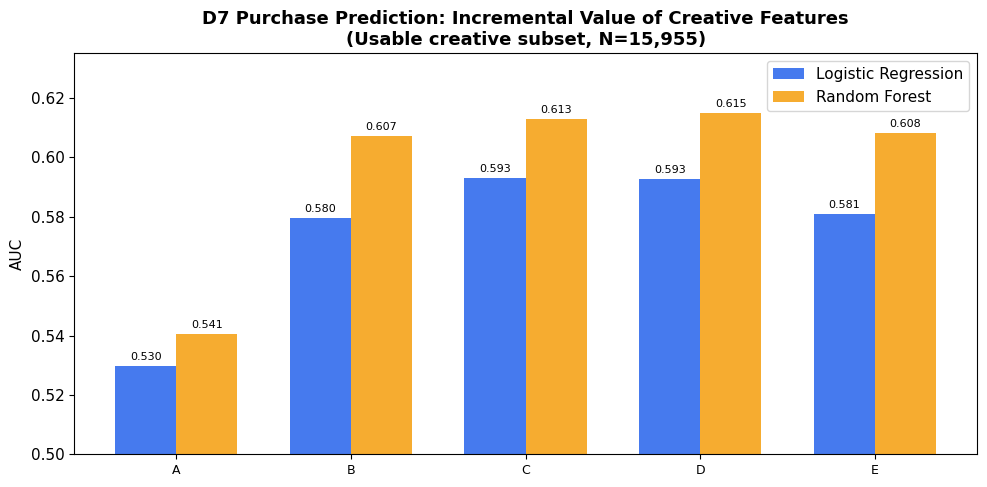

Saved: fig_creative_auc_comparison.png


In [10]:
# === 4.2 AUC Lift Visualization ===
fig, ax = plt.subplots(figsize=(10, 5))

model_names = list(results.keys())
auc_lr_vals = [results[n]['lr'] for n in model_names]
auc_rf_vals = [results[n]['rf'] for n in model_names]

x = np.arange(len(model_names))
w = 0.35
bars1 = ax.bar(x - w/2, auc_lr_vals, w, label='Logistic Regression', color=C_PRIMARY, alpha=0.85)
bars2 = ax.bar(x + w/2, auc_rf_vals, w, label='Random Forest', color=C_ACCENT, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([n.split(':')[0] for n in model_names], fontsize=9)
ax.set_ylabel('AUC')
ax.set_title('D7 Purchase Prediction: Incremental Value of Creative Features\n(Usable creative subset, N=15,955)', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, max(max(auc_lr_vals), max(auc_rf_vals)) + 0.02)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_creative_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_creative_auc_comparison.png')

---
# Part 5: Broken Image Analysis — The Meta Catalog Problem

**Question**: The 35,554 users with "broken images" (9.2%) likely come from Meta/Facebook catalog ads.
These have creative URLs but the images can't be scraped. What can we learn about this group?

In [11]:
# === 5.1 Broken Image (Meta Catalog) Analysis ===
print('=' * 70)
print('BROKEN IMAGE USERS — META CATALOG AD ANALYSIS')
print('=' * 70)

broken = df[has_url & has_broken & ~has_usable].copy()
usable_grp = df[has_usable].copy()
no_creative = df[~has_url].copy()

print(f'\nBroken image users: {len(broken):,}')
print(f'\n--- Channel Distribution ---')
for col, label in [('last_touch_is_da', 'DA'), ('last_touch_is_sa', 'SA')]:
    print(f'  {label}: broken={broken[col].mean()*100:.1f}%, usable={usable_grp[col].mean()*100:.1f}%, no_creative={no_creative[col].mean()*100:.1f}%')

print(f'\n--- Key Metrics Comparison ---')
print(f'{"Metric":<30} {"Broken":>10} {"Usable":>10} {"No Creative":>12}')
print('-' * 65)
for metric, label in [
    ('IS_D7_PURCHASE', 'D7 Purchase Rate'),
    ('IS_D7_CHURN', 'D7 Churn Rate'),
    ('IS_M10_CHURN', 'M10 Churn Rate'),
    ('IS_D30_PURCHASE', 'D30 Purchase Rate'),
]:
    v1 = broken[metric].mean()
    v2 = usable_grp[metric].mean()
    v3 = no_creative[metric].mean()
    print(f'{label:<30} {v1:>9.1%} {v2:>9.1%} {v3:>11.1%}')

print(f'\n--- UA Feature Comparison ---')
for feat in ['latency', 'total_touch_count', 'channel_entropy', 'DA_count', 'SA_count']:
    if feat in df.columns:
        v1 = broken[feat].mean()
        v2 = usable_grp[feat].mean()
        v3 = no_creative[feat].mean()
        print(f'{feat:<30} {v1:>10.2f} {v2:>10.2f} {v3:>12.2f}')

print('\n** Broken image users are predominantly DA users with low purchase rates **')
print('** Their poor metrics likely reflect DA channel characteristics, not creative quality **')

BROKEN IMAGE USERS — META CATALOG AD ANALYSIS



Broken image users: 35,554

--- Channel Distribution ---
  DA: broken=70.2%, usable=49.0%, no_creative=12.3%
  SA: broken=8.7%, usable=15.1%, no_creative=14.1%

--- Key Metrics Comparison ---
Metric                             Broken     Usable  No Creative
-----------------------------------------------------------------
D7 Purchase Rate                    7.4%     15.7%       16.3%
D7 Churn Rate                      51.2%     48.2%       45.4%
M10 Churn Rate                     32.3%     26.4%       23.0%
D30 Purchase Rate                  11.3%     20.6%       21.7%

--- UA Feature Comparison ---
latency                        1157703.09 1211918.52    553300.29
total_touch_count                   13.99      17.65        23.47
channel_entropy                      0.72       0.64         0.20
DA_count                             2.33       2.41         0.81
SA_count                             0.36       0.51         0.43

** Broken image users are predominantly DA users with low pur

---
# Part 6: Representativeness Check

**Question**: Is the usable creative subset representative of the full population?
If not, findings may not generalize.

In [12]:
# === 6.1 Representativeness of Usable Creative Subset ===
print('=' * 70)
print('REPRESENTATIVENESS CHECK: USABLE CREATIVE vs FULL POPULATION')
print('=' * 70)

full = df.copy()
usable_sub = df[has_usable].copy()

print(f'\n{"Metric":<35} {"Full Pop":>10} {"Usable":>10} {"Diff":>8}')
print('-' * 68)

for metric, label in [
    ('IS_D7_PURCHASE', 'D7 Purchase Rate'),
    ('IS_D7_CHURN', 'D7 Churn Rate'),
    ('IS_M10_CHURN', 'M10 Churn Rate'),
    ('has_touchpoint', 'Paid User Rate'),
    ('last_touch_is_da', 'DA Rate'),
    ('last_touch_is_sa', 'SA Rate'),
]:
    v_full = full[metric].mean()
    v_usable = usable_sub[metric].mean()
    print(f'{label:<35} {v_full:>9.1%} {v_usable:>9.1%} {v_usable - v_full:>+7.1%}p')

for feat in ['latency', 'total_touch_count']:
    if feat in df.columns:
        v_full = full[feat].mean()
        v_usable = usable_sub[feat].mean()
        print(f'{feat:<35} {v_full:>10.1f} {v_usable:>10.1f} {v_usable - v_full:>+8.1f}')

print('\n** Note: Usable creative subset is 100% paid users (has creative URL) **')
print('** Compare against paid-only population for fair comparison **')

# Fair comparison: usable vs paid-only
paid = df[df['has_touchpoint'] == 1].copy()
print(f'\n--- Fair Comparison: Usable Creative vs All Paid Users ---')
print(f'\n{"Metric":<35} {"All Paid":>10} {"Usable":>10} {"Diff":>8}')
print('-' * 68)
for metric, label in [
    ('IS_D7_PURCHASE', 'D7 Purchase Rate'),
    ('IS_D7_CHURN', 'D7 Churn Rate'),
    ('last_touch_is_da', 'DA Rate'),
    ('last_touch_is_sa', 'SA Rate'),
]:
    v_paid = paid[metric].mean()
    v_usable = usable_sub[metric].mean()
    print(f'{label:<35} {v_paid:>9.1%} {v_usable:>9.1%} {v_usable - v_paid:>+7.1%}p')

REPRESENTATIVENESS CHECK: USABLE CREATIVE vs FULL POPULATION

Metric                                Full Pop     Usable     Diff
--------------------------------------------------------------------
D7 Purchase Rate                        15.4%     15.7%   +0.3%p
D7 Churn Rate                           46.1%     48.2%   +2.1%p
M10 Churn Rate                          24.0%     26.4%   +2.4%p
Paid User Rate                          85.4%    100.0%  +14.6%p
DA Rate                                 19.2%     49.0%  +29.9%p
SA Rate                                 13.6%     15.1%   +1.5%p
latency                               636404.5  1211918.5 +575514.0
total_touch_count                         22.4       17.6     -4.7

** Note: Usable creative subset is 100% paid users (has creative URL) **
** Compare against paid-only population for fair comparison **



--- Fair Comparison: Usable Creative vs All Paid Users ---

Metric                                All Paid     Usable     Diff
--------------------------------------------------------------------
D7 Purchase Rate                        15.8%     15.7%   -0.0%p
D7 Churn Rate                           46.5%     48.2%   +1.7%p
DA Rate                                 22.4%     49.0%  +26.6%p
SA Rate                                 15.9%     15.1%   -0.8%p


---
# Part 7: Feature Importance — Which Creative Features Matter Most?

CREATIVE FEATURE IMPORTANCE (Random Forest)



Top 15 Creative Features by RF Importance:
Feature                               Importance   % of total
--------------------------------------------------------------
hue_sin                                   0.0239         2.4%
hue_cos                                   0.0237         2.4%
brightness_mean                           0.0233         2.3%
vertical_symmetry_score                   0.0212         2.1%
saturation_mean                           0.0204         2.0%
edge_density                              0.0197         2.0%
symmetry_score                            0.0184         1.8%
color_entropy                             0.0183         1.8%
llm_brand_trust                           0.0066         0.7%
llm_product_attribute                     0.0043         0.4%
rule_percent                              0.0037         0.4%
rule_discount_word                        0.0037         0.4%
rule_coupon                               0.0036         0.4%
rule_date_format         

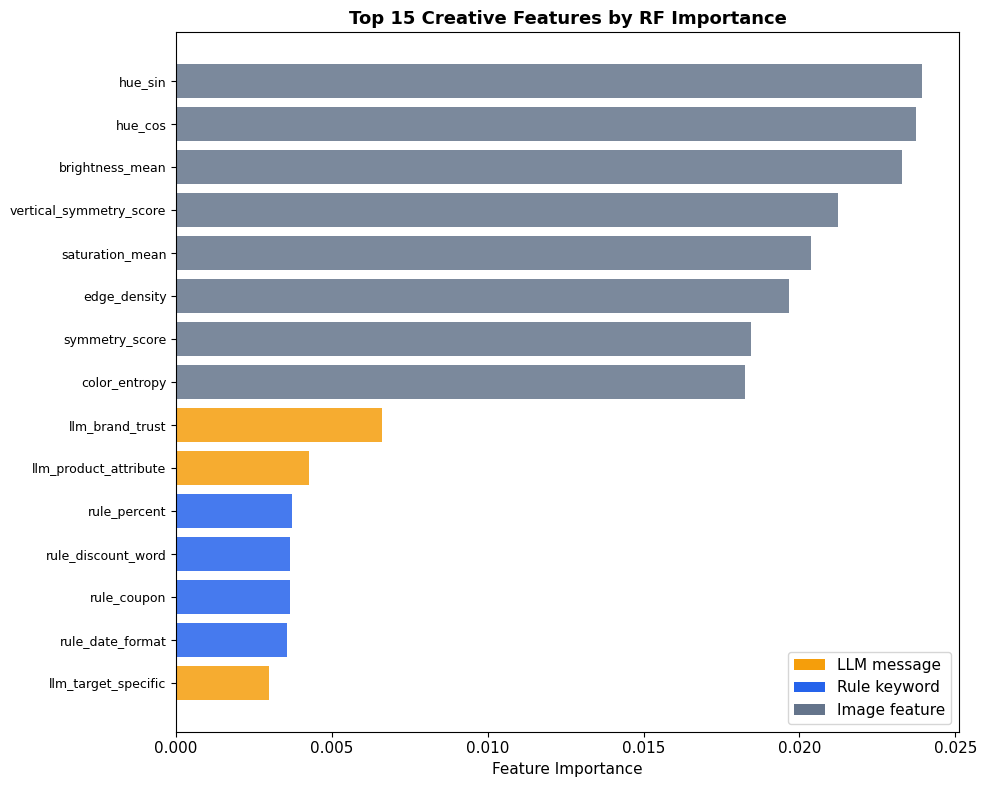

Saved: fig_creative_feature_importance.png


In [13]:
# === 7.1 Creative Feature Importance (RF) ===
print('=' * 70)
print('CREATIVE FEATURE IMPORTANCE (Random Forest)')
print('=' * 70)

usable = df[has_usable].copy()
for col in DEVICE_FEATURES:
    if usable[col].dtype == 'object':
        usable[col] = usable[col].astype('category').cat.codes

# Train RF on Device + UA + Creative, extract creative feature importances
all_feats = list(DEVICE_FEATURES) + ua_cols + creative_cols_clean
X = usable[all_feats].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0).values
y = usable['IS_D7_PURCHASE'].values

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=all_feats)
creative_imp = importances[creative_cols_clean].sort_values(ascending=False)

print(f'\nTop 15 Creative Features by RF Importance:')
print(f'{"Feature":<35} {"Importance":>12} {"% of total":>12}')
print('-' * 62)
total_imp = importances.sum()
for feat, imp in creative_imp.head(15).items():
    print(f'{feat:<35} {imp:>12.4f} {imp/total_imp*100:>11.1f}%')

print(f'\nTotal creative importance: {creative_imp.sum():.4f} ({creative_imp.sum()/total_imp*100:.1f}% of all features)')
print(f'Total UA importance: {importances[ua_cols].sum():.4f} ({importances[ua_cols].sum()/total_imp*100:.1f}%)')
print(f'Total device importance: {importances[list(DEVICE_FEATURES)].sum():.4f} ({importances[list(DEVICE_FEATURES)].sum()/total_imp*100:.1f}%)')

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))
top_creative = creative_imp.head(15)
colors_bar = [C_ACCENT if f.startswith('llm_') else C_PRIMARY if f.startswith('rule_') else C_SECONDARY for f in top_creative.index]
ax.barh(range(len(top_creative)), top_creative.values, color=colors_bar, alpha=0.85)
ax.set_yticks(range(len(top_creative)))
ax.set_yticklabels(top_creative.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Creative Features by RF Importance', fontsize=13, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=C_ACCENT, label='LLM message'),
                   Patch(facecolor=C_PRIMARY, label='Rule keyword'),
                   Patch(facecolor=C_SECONDARY, label='Image feature')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('fig_creative_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_creative_feature_importance.png')

---
# Executive Summary

In [14]:
# === Executive Summary ===
print('=' * 80)
print('CREATIVE FEATURE ANALYSIS: KEY FINDINGS')
print('=' * 80)

print('''
1. COVERAGE
   - 13.4% of users have creative URLs (51,509)
   - Only 4.1% have fully analyzable creative (15,955)
   - 9.2% have "broken" images — mostly Meta catalog ads (70% DA users)

2. MESSAGE TYPE SIGNALS (within usable subset)
   - Brand trust messages: +2.4%p purchase rate (16.9% vs 14.5%)
   - "First come first served": +4.6%p (20.3% vs 15.7%)
   - "Half price": +3.8%p (19.4% vs 15.7%)
   - Coupon-driven users: -4.0%p (12.1% vs 16.1%)
   - Social proof messages: -2.9%p (13.0% vs 15.9%)
   → Ad message TYPE reveals user intent quality

3. IMAGE FEATURES
   - All correlations < ±0.03 — no meaningful signal
   - Image-only model adds minimal AUC over Device+UA
   → Visual properties of ads do not predict behavior

4. INCREMENTAL AUC
   - Text features (LLM+Rule) add meaningful AUC over Device+UA
   - Image features add negligible AUC
   → The VALUE is in what the ad SAID, not how it LOOKED

5. PRACTICAL IMPLICATION
   - Even with only 4.1% coverage, creative text signals show clear value
   - If MMP creative data collection is expanded (especially OCR/text),
     personalization precision could improve significantly
   - Priority: text/message extraction >> image analysis
   - Meta catalog ads (9.2%) represent untapped potential if creative
     scraping can be resolved
''')

CREATIVE FEATURE ANALYSIS: KEY FINDINGS

1. COVERAGE
   - 13.4% of users have creative URLs (51,509)
   - Only 4.1% have fully analyzable creative (15,955)
   - 9.2% have "broken" images — mostly Meta catalog ads (70% DA users)

2. MESSAGE TYPE SIGNALS (within usable subset)
   - Brand trust messages: +2.4%p purchase rate (16.9% vs 14.5%)
   - "First come first served": +4.6%p (20.3% vs 15.7%)
   - "Half price": +3.8%p (19.4% vs 15.7%)
   - Coupon-driven users: -4.0%p (12.1% vs 16.1%)
   - Social proof messages: -2.9%p (13.0% vs 15.9%)
   → Ad message TYPE reveals user intent quality

3. IMAGE FEATURES
   - All correlations < ±0.03 — no meaningful signal
   - Image-only model adds minimal AUC over Device+UA
   → Visual properties of ads do not predict behavior

4. INCREMENTAL AUC
   - Text features (LLM+Rule) add meaningful AUC over Device+UA
   - Image features add negligible AUC
   → The VALUE is in what the ad SAID, not how it LOOKED

5. PRACTICAL IMPLICATION
   - Even with only 4.1